In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [84]:
# data: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
data = pd.read_csv('../datasets/Life Expectancy Data.csv')
data.columns = [col.strip() for col in data.columns.values]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

### Dataset Description: Life Expectancy & Health Indicators

| Column Name | Description |
|-------------|-------------|
| **Country** | Country observed |
| **Year** | Year observed |
| **Status** | Developed or Developing status |
| **Life.expectancy** | Life expectancy in age |
| **Adult.Mortality** | Adult mortality rates on both sexes (probability of dying between 15-60 years per 1000 population) |
| **infant.deaths** | Number of infant deaths per 1000 population |
| **Alcohol** | Alcohol recorded per capita (15+) consumption (in litres of pure alcohol) |
| **percentage.expenditure** | Expenditure on health as a percentage of Gross Domestic Product per capita (%) |
| **Hepatitis.B** | Hepatitis B (HepB) immunization coverage among 1-year-olds (%) |
| **Measles** | Number of reported measles cases per 1000 population |
| **BMI** | Average Body Mass Index of entire population |
| **under.five.deaths** | Number of under-five deaths per 1000 population |
| **Polio** | Polio (Pol3) immunization coverage among 1-year-olds (%) |
| **Total.expenditure** | General government expenditure on health as a percentage of total government expenditure (%) |
| **Diphtheria** | Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%) |
| **HIV.AIDS** | Deaths per 1000 live births due to HIV/AIDS (0-4 years) |
| **GDP** | Gross Domestic Product per capita (in USD) |
| **Population** | Population of the country |
| **thinness..1.19.years** | Prevalence of thinness among children and adolescents for Age 10 to 19 (%) |
| **thinness.5.9.years** | Prevalence of thinness among children for Age 5 to 9 (%) |
| **Income.composition.of.resources** | Human Development Index in terms of income composition of resources (index ranging from 0 to 1) |
| **Schooling** | Number of years of schooling (years) |

In [66]:
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### EDA (Exploratory Data Analysis)

In [67]:
data.isna().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [69]:
data.drop('Country', axis=1).corr()['Life expectancy'].sort_values(ascending=False)

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Status                             0.482136
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Total expenditure                  0.218086
Year                               0.170033
Population                        -0.021538
Measles                           -0.157586
infant deaths                     -0.196557
under-five deaths                 -0.222529
thinness 5-9 years                -0.471584
thinness  1-19 years              -0.477183
HIV/AIDS                          -0.556556
Adult Mortality                   -0.696359
Name: Life expectancy, dtype: float64

### Model

In [85]:
# drop the row where Life expectancy is nan
data = data.dropna(subset=['Life expectancy'])

# encode categorical variable
data['Status'] = data['Status'].map({'Developing': 0, 'Developed': 1})

# feature selection (top and bottom fields of correlation matrix)
feature_columns = ['Schooling', 'Income composition of resources', 'BMI', 'Status', 
            'Diphtheria', 'Polio', 'GDP', 'Alcohol', 'thinness 5-9 years',
            'thinness  1-19 years', 'HIV/AIDS', 'Adult Mortality']

X = data[feature_columns]
y = data['Life expectancy']

#fill na of features
for col in X.columns:
    X.loc[:, col] = X.loc[:, col].fillna(X.loc[:, col].median())

# data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
X_train.head()

,Schooling,Income composition of resources,BMI,Status,Diphtheria,Polio,GDP,Alcohol,thinness 5-9 years,thinness 1-19 years,HIV/AIDS,Adult Mortality
2268,14.0,0.767,58.3,0,91.0,93.0,5659.382400,9.38,2.1,2.1,0.1,126.0
1680,12.5,0.683,26.4,0,88.0,88.0,3957.512960,4.14,7.9,7.9,0.1,179.0
2785,12.3,0.677,19.6,0,86.0,89.0,1764.973870,3.44,7.3,7.3,7.4,376.0
2512,15.7,0.897,56.5,1,98.0,98.0,55746.842380,6.90,1.3,1.3,0.1,62.0
1090,9.2,0.421,26.3,0,87.0,87.0,596.871719,3.77,7.0,7.1,3.2,275.0


In [88]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,Schooling,Income composition of resources,BMI,Status,Diphtheria,Polio,GDP,Alcohol,thinness 5-9 years,thinness 1-19 years,HIV/AIDS,Adult Mortality
0,0.609119,0.676827,1.011843,-0.457259,0.374228,0.452644,-0.068959,1.238372,-0.619571,-0.623696,-0.326377,-0.322817
1,0.148097,0.262627,-0.587068,-0.457259,0.249314,0.238553,-0.197190,-0.105060,0.664257,0.688496,-0.326377,0.103723
2,0.086627,0.233041,-0.927902,-0.457259,0.166037,0.281371,-0.362391,-0.284526,0.531447,0.552752,1.082164,1.689162
3,1.131611,1.317852,0.921622,2.186942,0.665696,0.666734,3.704993,0.602549,-0.796651,-0.804688,-0.326377,-0.837884
4,-0.866153,-1.029283,-0.592080,-0.457259,0.207675,0.195735,-0.450405,-0.199921,0.465042,0.507504,0.271771,0.876322


In [91]:
# model 
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
# predict
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [125]:
# equation
slope = model.coef_
intercept = model.intercept_

print("\n" + "="*50)
print("LINEAR REGRESSION:")
print("="*50)
variables = [f"({intercept:0.2f})"] + [f"({s:0.2f} * {col})" for col, s in zip(feature_columns, slope)]
equation = " + \n".join(variables)
print(f"Life expectancy = \n{equation}")


LINEAR REGRESSION:
Life expectancy = 
(69.15) + 
(2.26 * Schooling) + 
(1.20 * Income composition of resources) + 
(0.90 * BMI) + 
(0.55 * Status) + 
(1.01 * Diphtheria) + 
(0.76 * Polio) + 
(0.59 * GDP) + 
(0.14 * Alcohol) + 
(0.14 * thinness 5-9 years) + 
(-0.61 * thinness  1-19 years) + 
(-2.50 * HIV/AIDS) + 
(-2.58 * Adult Mortality)


In [136]:
# feature_importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': model_multi.coef_
})
feature_importance['abs_coefficient'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
11,Adult Mortality,-2.579529,2.579529
10,HIV/AIDS,-2.500417,2.500417
0,Schooling,2.255609,2.255609
1,Income composition of resources,1.202334,1.202334
4,Diphtheria,1.010496,1.010496
2,BMI,0.901868,0.901868
5,Polio,0.758771,0.758771
9,thinness 1-19 years,-0.608257,0.608257
6,GDP,0.587542,0.587542
3,Status,0.547549,0.547549


In [153]:
# performance metrics
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print(f"Model Performance:")
print("="*50)

print(f"\n📊 R²")
print(f"   • Model explains {r2_test*100:.1f}% of the variation in life expectancy")
print(f"   • Only {100-r2_test*100:.1f}% of variation is unexplained (due to other factors)")
print(f"Training R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")


if abs(r2_train - r2_test) < 0.05:
    print("✅ Good: Training and testing R² are similar - no overfitting")
else:
    print(f"⚠️  Warning: Difference of {abs(r2_train - r2_test):.3f} between training and testing R²")

print()

print(f"\n📊 MSE:")
print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")

print()

print(f"\n📊 RMSE")
print(f"   • Predictions are off by ±{rmse_test:.2f} years on average")
print(f"   • In other words, 68% of predictions fall within {rmse_test:.2f} years of actual value")
print(f"   • 95% of predictions fall within {rmse_test*2:.2f} years of actual value")
print(f"Training RMSE: {rmse_train:.2f} years")
print(f"Testing RMSE: {rmse_test:.2f} years")
if rmse_test < 3:
    print("✅ Excellent: Very precise predictions (within 3 years)")
elif rmse_test < 5:
    print("✅ Good: Reasonably precise predictions (within 5 years)")
elif rmse_test < 7:
    print("⚠️  Moderate: Predictions may need improvement")
else:
    print("❌ Poor: High uncertainty in predictions")

print()

print(f"\n📊 MAE:")
print(f"Training MAE: {mae_train:.2f} years")
print(f"Testing MAE: {mae_test:.2f} years")


Model Performance:

📊 R²
   • Model explains 80.9% of the variation in life expectancy
   • Only 19.1% of variation is unexplained (due to other factors)
Training R²: 0.8075
Test R²: 0.8093
✅ Good: Training and testing R² are similar - no overfitting


📊 MSE:
Training MSE: 17.65
Test MSE: 16.49


📊 RMSE
   • Predictions are off by ±4.06 years on average
   • In other words, 68% of predictions fall within 4.06 years of actual value
   • 95% of predictions fall within 8.12 years of actual value
Training RMSE: 4.20 years
Testing RMSE: 4.06 years
✅ Good: Reasonably precise predictions (within 5 years)


📊 MAE:
Training MAE: 3.13 years
Testing MAE: 3.00 years


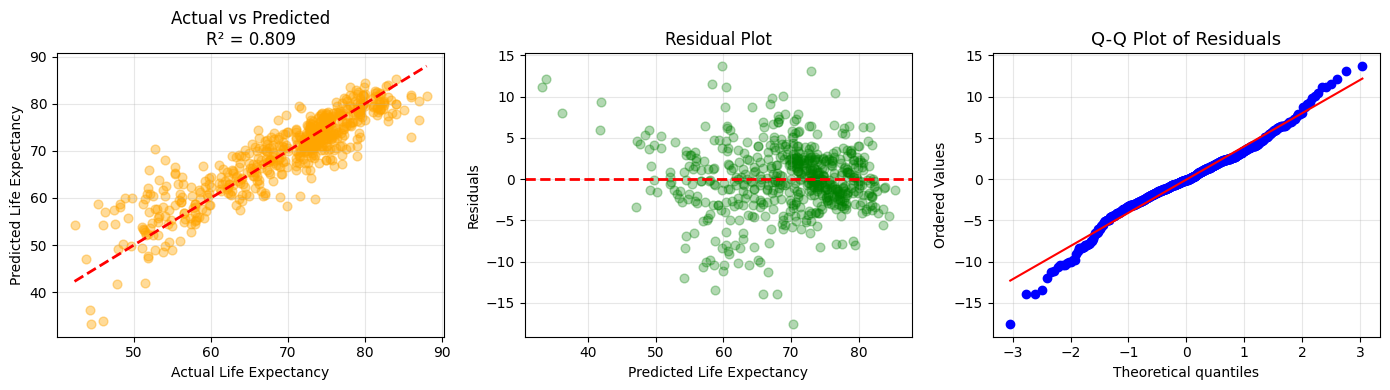

In [175]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_test_pred, alpha=0.4, s=40, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title(f'Actual vs Predicted\nR² = {r2_test:.3f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.3, s=40, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Life Expectancy')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals', fontsize=13)
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()